In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

In [3]:
dataframe = pd.read_csv('analisis.csv')
dataframe.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [4]:
dataframe.describe()

,op,co,ex,ag,ne,wordcount,categoria
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,44.414591,22.977135,40.764428,22.918528,8.000098,98.715484,4.050000
std,8.425723,5.816851,7.185246,7.657122,3.039248,44.714071,2.658839
min,30.020465,7.852756,18.693542,9.305985,1.030213,5.020800,1.000000
25%,38.206484,19.740299,36.095722,17.050993,6.086144,66.218475,2.000000
50%,44.507091,22.466718,41.457492,21.384554,7.839722,94.711400,3.500000
75%,49.365923,26.091606,45.197769,28.678866,9.758189,119.707925,7.000000
max,71.696129,49.637863,59.824844,40.583162,23.978462,217.183200,9.000000


In [5]:
print(dataframe.groupby('categoria').size())

categoria
1    27
2    34
3     9
4    19
5     4
6     8
7    17
8    16
9     6
dtype: int64


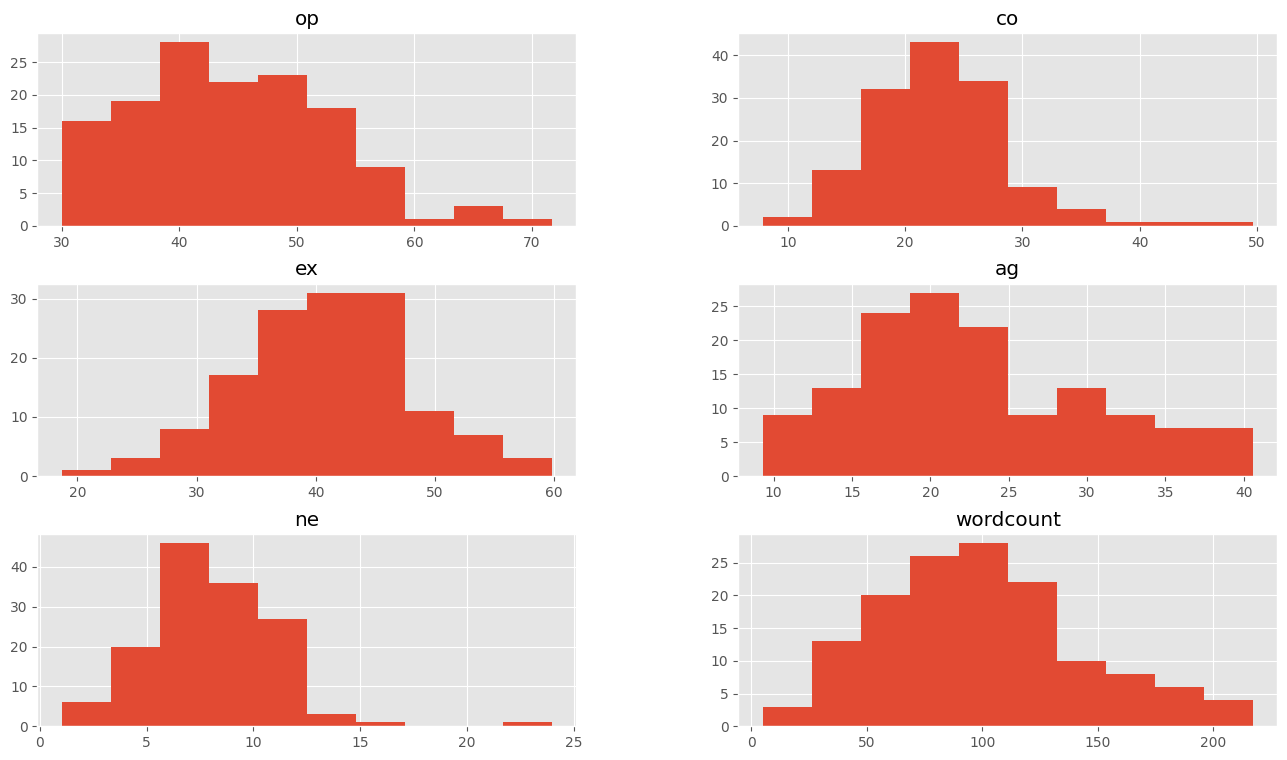

In [6]:
dataframe.drop(['categoria'], axis = 1).hist()
plt.show()

/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


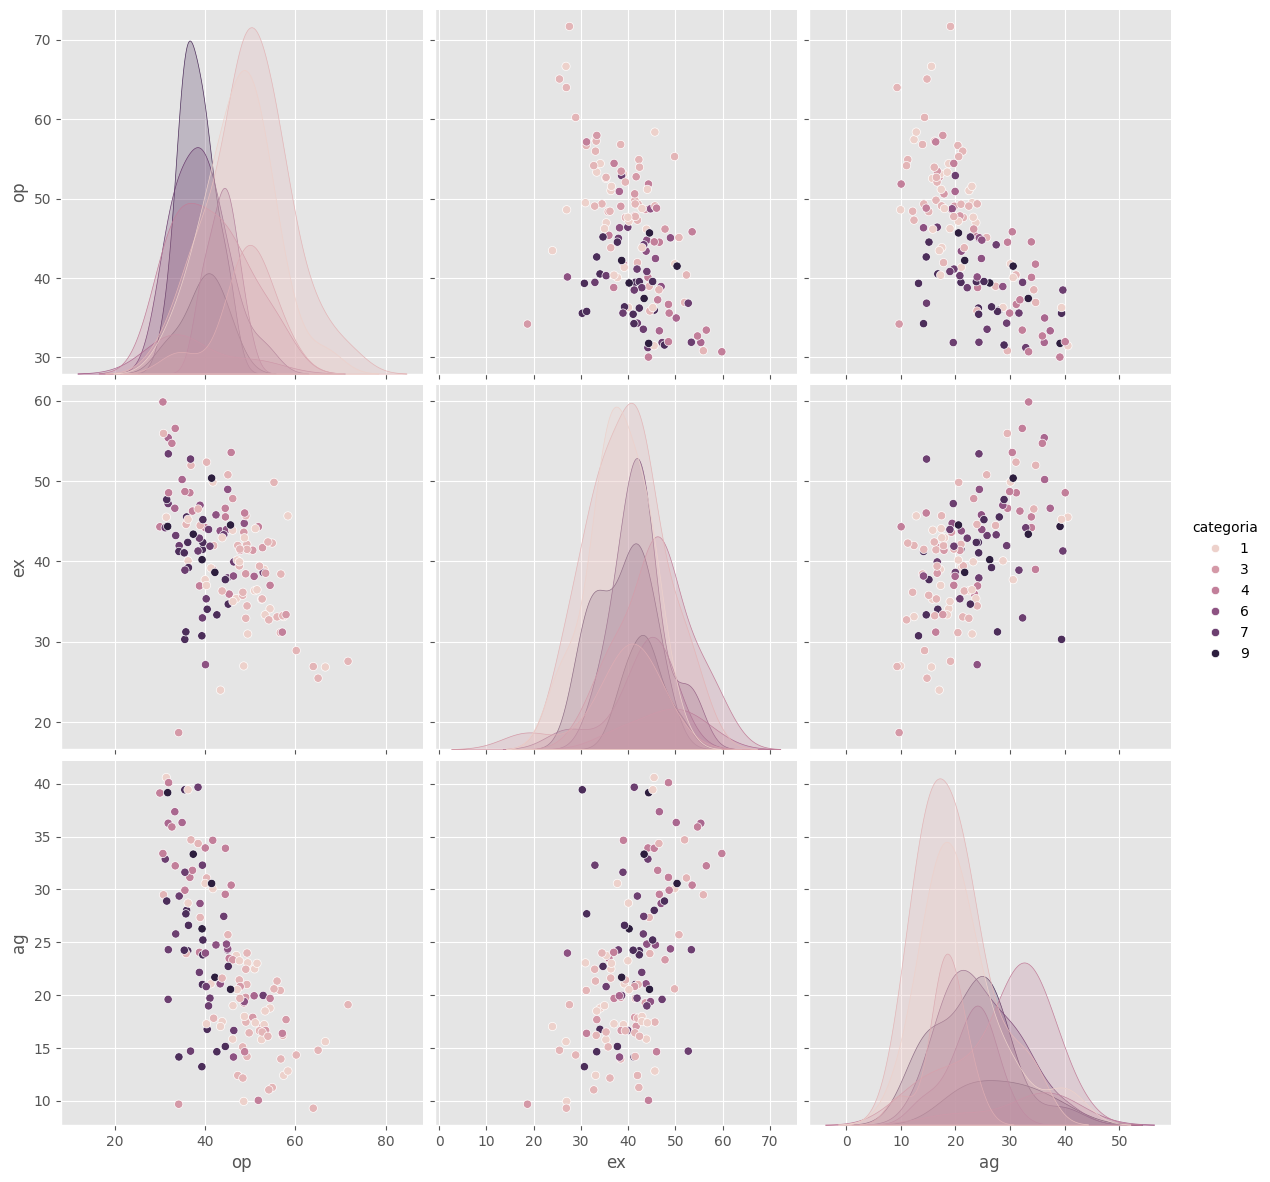

In [7]:
sb.pairplot(dataframe.dropna(), hue = 'categoria', size = 4, vars = ['op', 'ex', 'ag'], kind = 'scatter')

In [8]:
X = np.array(dataframe[['op', 'ex', 'ag']])
y = np.array(dataframe['categoria'])
X.shape

fig = plt.figure()
ax = Axes3D(fig)
colores = ['blue', 'red', 'green', 'blue', 'cyan', 'yellow', 'orange', 'black', 'pink', 'brown', 'purple']
asignar = []
for row in y:
    asignar.append(colores[row])
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = asignar, s = 60)

<Figure size 1600x900 with 0 Axes>

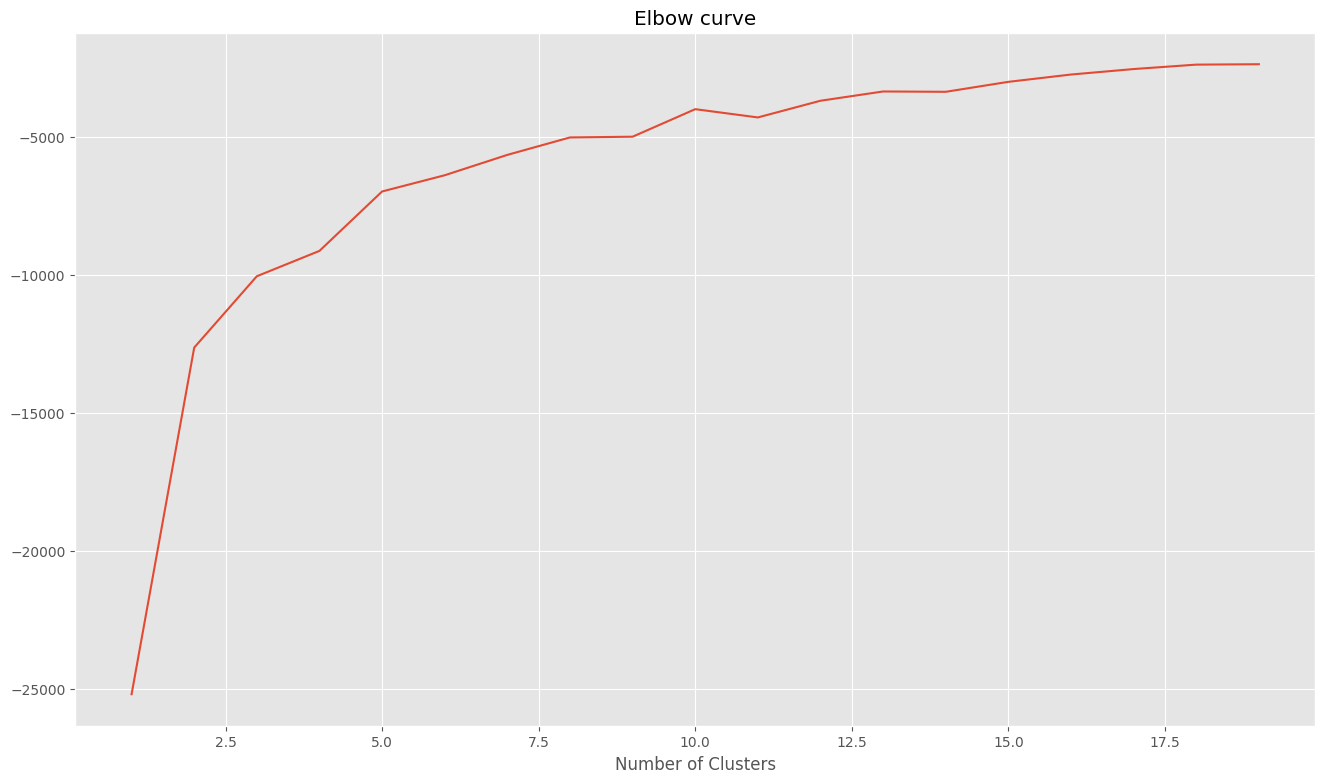

In [9]:
Nc = range(1, 20)
kmeans = [KMeans(n_clusters = i) for i in Nc]
kmeans
score = [kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc, score)
plt.xlabel('Number of Clusters')
plt.title('Elbow curve')
plt.show()

In [10]:
kmeans = KMeans(n_clusters = 5).fit(X)
centroids = kmeans.cluster_centers_
print(centroids)

[[47.52267872 40.66459598 19.10784798]
 [36.36072461 49.00055455 33.35928723]
 [57.8660089  33.5023241  15.83714586]
 [41.25709443 27.84871157 15.040178  ]
 [37.80184307 40.50462041 26.10262622]]


In [11]:
labels = kmeans.predict(X)
C = kmeans.cluster_centers_
colores = ['red', 'green', 'blue', 'cyan', 'yellow']
asignar = []
for row in labels:
    asignar.append(colores[row])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = asignar, s = 60)
ax.scatter(C[:, 0], C[:, 1], C[:, 2], marker = '*', c = colores, s = 1000)

<Figure size 1600x900 with 0 Axes>

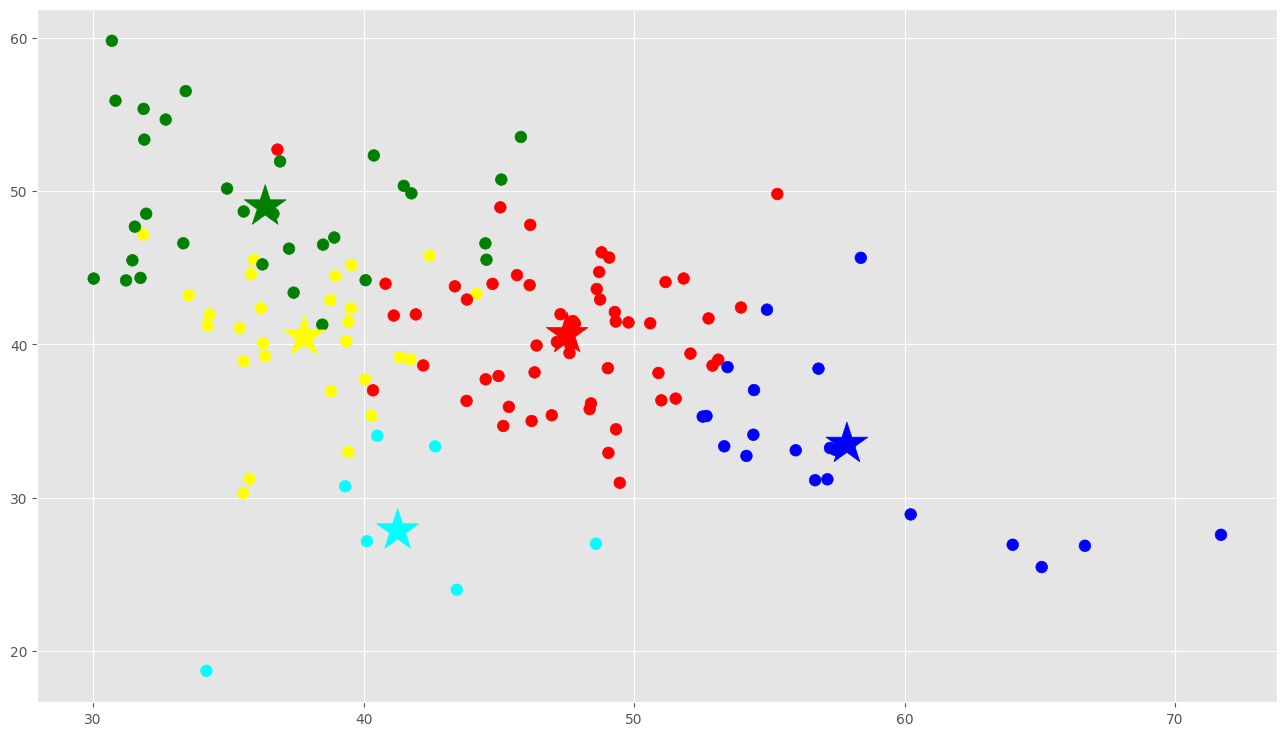

In [12]:
f1 = dataframe['op'].values
f2 = dataframe['ex'].values

plt.scatter(f1, f2, c = asignar, s = 70)
plt.scatter(C[:, 0], C[: ,1], marker = '*', c = colores, s = 1000)
plt.show()

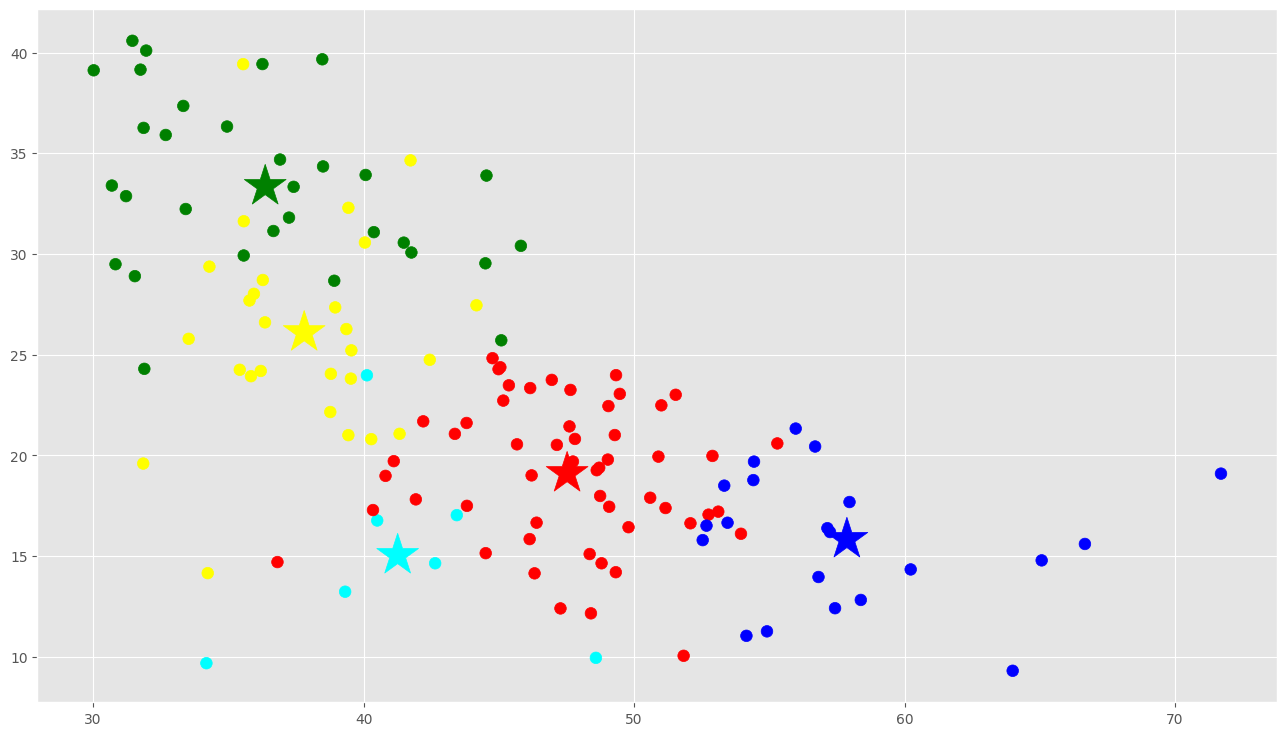

In [14]:
f1 = dataframe['op'].values
f2 = dataframe['ag'].values

plt.scatter(f1, f2, c = asignar, s = 70)
plt.scatter(C[:, 0], C[: ,2], marker = '*', c = colores, s = 1000)
plt.show()

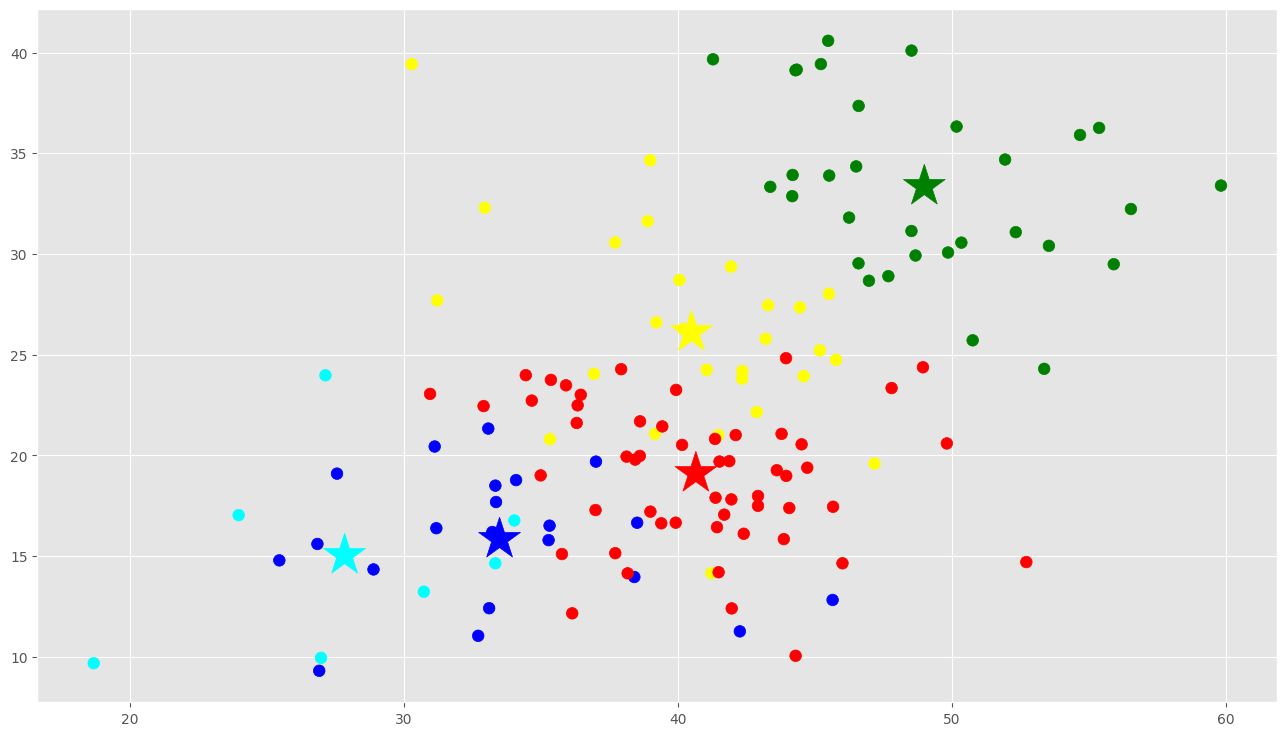

In [15]:
f1 = dataframe['ex'].values
f2 = dataframe['ag'].values

plt.scatter(f1, f2, c = asignar, s = 70)
plt.scatter(C[:, 1], C[: ,2], marker = '*', c = colores, s = 1000)
plt.show()

In [17]:
copy = pd.DataFrame()
copy['usuario'] = dataframe['usuario'].values
copy['categoria'] = dataframe['categoria'].values
copy['labels'] = labels;
cantidadGrupo = pd.DataFrame()
cantidadGrupo['color'] = colores
cantidadGrupo['cantidad'] = copy.groupby('labels').size()
cantidadGrupo

,color,cantidad
0,red,54
1,green,31
2,blue,21
3,cyan,7
4,yellow,27


In [18]:
group_referrer_index = copy['labels'] == 0
group_referrals = copy[group_referrer_index]

diversidadGrupo = pd.DataFrame()
diversidadGrupo['categoria'] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
diversidadGrupo['cantidad'] = group_referrals.groupby('categoria').size()
diversidadGrupo

,categoria,cantidad
0,0,NaN
1,1,13.0
2,2,16.0
3,3,6.0
4,4,3.0
5,5,1.0
6,6,5.0
7,7,6.0
8,8,2.0
9,9,2.0


In [19]:
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
closest

array([ 93,   4,  75, 116,  65])

In [20]:
users = dataframe['usuario'].values
for row in closest:
    print(users[row])

LennyKravitz
alfredocasero1
JLo
Rep_Hunter
iescolar


In [22]:
X_new = np.array([[45.92,57.74,15.66]])

new_labels = kmeans.predict(X_new)
print(new_labels)

[0]
